<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/NASSCOM_Day_2_Python_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')   # nicer default plot styling
np.random.seed(42)                 # reproducible results
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [2]:
# -----------------------------------------------------------
# 🔹 1A. ARRAY CREATION & SHAPE
# -----------------------------------------------------------

# arange() builds a range; reshape() changes the shape without copying data
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)

# Inspect the array's structure
print('shape :', a.shape)     # (2, 3)  -> 2 rows, 3 cols
print('ndim  :', a.ndim)      # 2       -> number of dimensions
print('dtype :', a.dtype)     # int64   -> data type of elements

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [3]:
# -----------------------------------------------------------
# 🔹 1B. SLICING & INDEXING
# -----------------------------------------------------------

print('Column index 1 :', a[:, 1])        # all rows, 2nd column
print('Row index 0    :', a[0, :])        # 1st row, all columns

# Boolean mask: keep only the elements that satisfy a condition
print('Elements > 2   :', a[a > 2])

Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]


In [4]:
# -----------------------------------------------------------
# 🔹 1C. BROADCASTING
# -----------------------------------------------------------

# Broadcasting lets NumPy combine arrays of different shapes without loops
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)

a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [5]:

# -----------------------------------------------------------
# 🔹 1D. MATRIX MULTIPLICATION + AXIS-WISE OPERATIONS  (core demo)
# -----------------------------------------------------------

b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)

# Axis-wise reductions: axis=0 collapses rows, axis=1 collapses columns
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [6]:
# Given data
M = np.arange(1, 13).reshape(3, 4)   # shape (3, 4)
N = np.arange(1, 9).reshape(4, 2)    # shape (4, 2)
print('M:\n', M)
print('N:\n', N)

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]


In [7]:
print('Matrix product M @ N:\n', M @ N)   # (3,4) @ (4,2) -> (3,2)

Matrix product M @ N:
 [[ 50  60]
 [114 140]
 [178 220]]


In [8]:
print('Column-wise sum of M (axis=0):', M.sum(axis=0))
print('Row-wise mean of M (axis=1):', M.mean(axis=1))

Column-wise sum of M (axis=0): [15 18 21 24]
Row-wise mean of M (axis=1): [ 2.5  6.5 10.5]


In [9]:
print('Index of max per row of M (axis=1):', M.argmax(axis=1))

Index of max per row of M (axis=1): [3 3 3]


In [10]:

# -----------------------------------------------------------
# 🔹 2A. LOAD & INSPECT
# -----------------------------------------------------------

# Load the classic Titanic dataset (built into seaborn).
# In your own work this would be: pd.read_csv('titanic.csv')
df = sns.load_dataset('titanic')

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
# .info() shows columns, dtypes and non-null counts -> spot missing data fast
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [12]:
# .describe() gives summary statistics for the numeric columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
# -----------------------------------------------------------
# 🔹 2B. HANDLE MISSING VALUES
# -----------------------------------------------------------

# Count missing values per column
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())

# Fill missing 'age' with the median (a common, robust strategy)
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())

Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

Missing ages after fillna: 0


In [14]:
# -----------------------------------------------------------
# 🔹 2C. GROUP BY A CATEGORY  (split -> apply -> combine)
# -----------------------------------------------------------

# Average survival rate by passenger class
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())

# Two-level grouping: survival by class AND sex
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())

Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Survival rate by class and sex:
class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


In [15]:
lab = sns.load_dataset('titanic')

In [16]:
print("Missing values in 'embarked':", df['embarked'].isna().sum())

Missing values in 'embarked': 2


In [17]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
print("Missing values in 'embarked' after fillna:", df['embarked'].isna().sum())

Missing values in 'embarked' after fillna: 0


In [18]:
print('Mean fare grouped by sex:')
print(df.groupby('sex')['fare'].mean())

Mean fare grouped by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


/tmp/ipykernel_1645/1142315389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='fare', data=mean_fare_by_sex, palette='viridis')


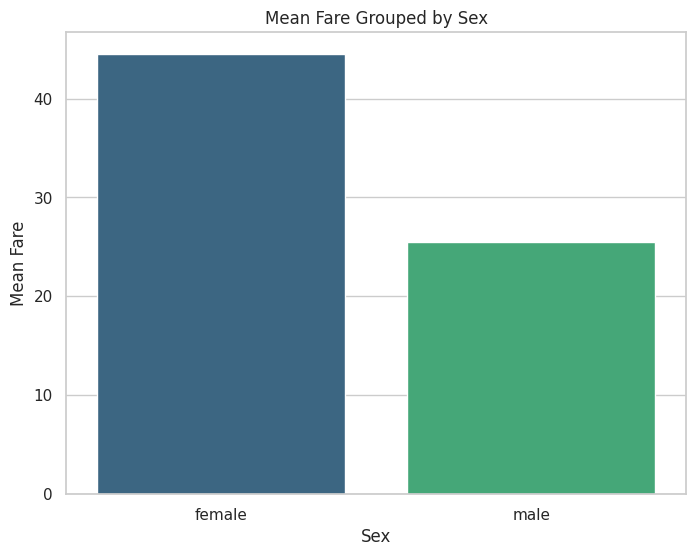

In [20]:
mean_fare_by_sex = df.groupby('sex')['fare'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='fare', data=mean_fare_by_sex, palette='viridis')
plt.title('Mean Fare Grouped by Sex')
plt.xlabel('Sex')
plt.ylabel('Mean Fare')
plt.show()

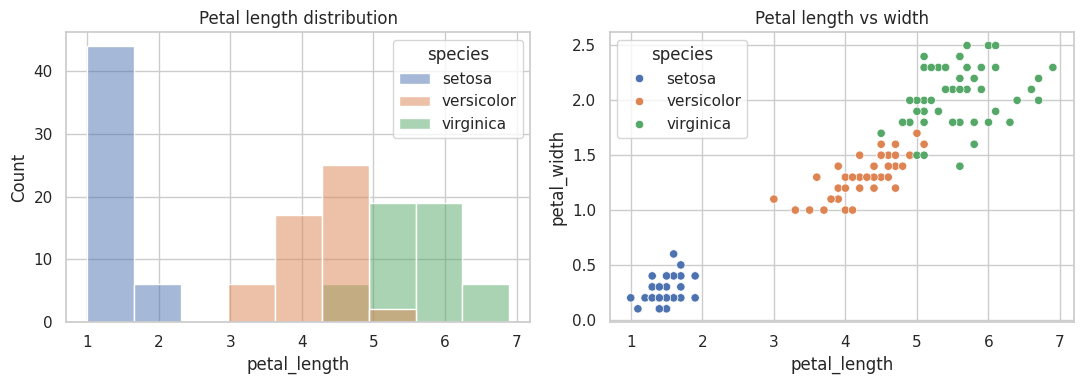

In [19]:

# -----------------------------------------------------------
# 🔹 3A. SUBPLOT COMPARISON  (Matplotlib)
# -----------------------------------------------------------

iris = sns.load_dataset('iris')   # 150 flowers, 4 measurements, 3 species

# plt.subplots() makes a grid of axes for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()

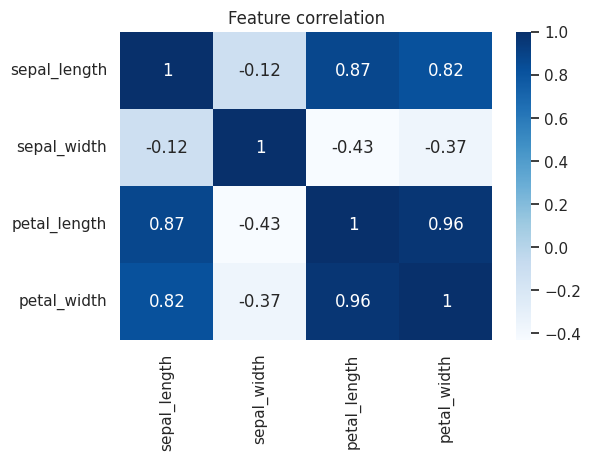

In [21]:
# -----------------------------------------------------------
# 🔹 3B. CORRELATION HEATMAP  (Seaborn)
# -----------------------------------------------------------

# .corr() on the numeric columns, visualised as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()


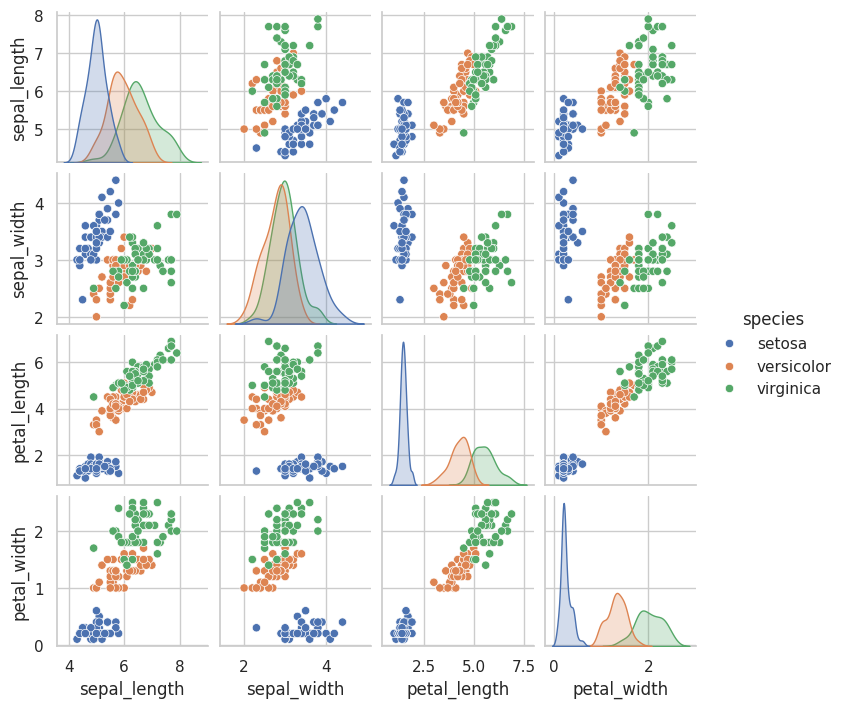

In [22]:
# -----------------------------------------------------------
# 🔹 3C. PAIRPLOT  (every feature vs every feature)
# -----------------------------------------------------------

# A pairplot draws scatter plots for all feature pairs at once,
# coloured by class -> a fast way to see how separable the classes are.
sns.pairplot(iris, hue='species', height=1.8)
plt.show()


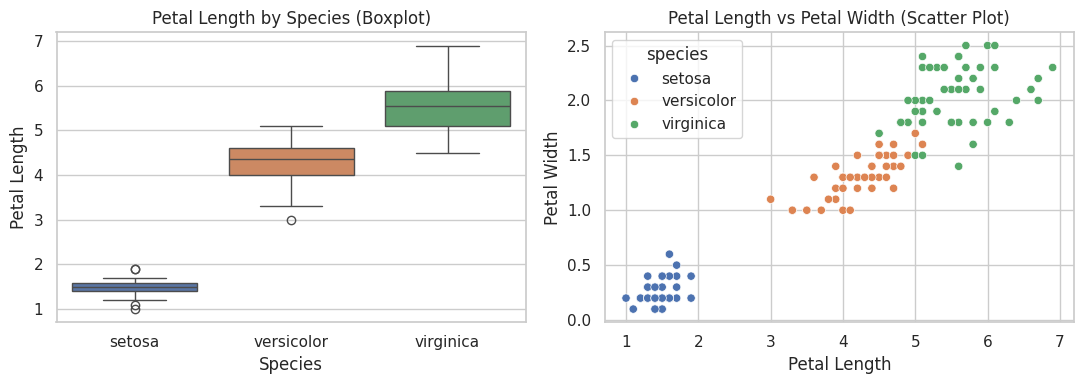

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=iris, x='species', y='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal Length by Species (Boxplot)')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Petal Length')

sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width (Scatter Plot)')
axes[1].set_xlabel('Petal Length')
axes[1].set_ylabel('Petal Width')

plt.tight_layout()
plt.show()

In [23]:
pen = sns.load_dataset('penguins')

### Drop rows with missing values

In [26]:
# Drop rows with missing values
print(f"Shape of DataFrame before dropping NA: {df.shape}")
df.dropna(inplace=True)
print(f"Shape of DataFrame after dropping NA: {df.shape}")

Shape of DataFrame before dropping NA: (201, 15)
Shape of DataFrame after dropping NA: (201, 15)


In [28]:
# -----------------------------------------------------------
# 🔹 4A. LOAD DATA & SPLIT
# -----------------------------------------------------------

# Load iris as feature matrix X and target vector y
X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

# Hold out 20% of the data for testing. stratify keeps class balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples


In [29]:

# -----------------------------------------------------------
# 🔹 4B. FIT -> PREDICT -> EVALUATE  (the estimator API)
# -----------------------------------------------------------

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)               # learn from training data
pred = clf.predict(X_test)              # score new samples

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [30]:
# -----------------------------------------------------------
# 🔹 4C. PIPELINE  (preprocessing + model as one object)
# -----------------------------------------------------------

# A Pipeline chains steps so the SAME transform runs on train and test
# data -> no leakage, and a single .fit() / .predict() call.
pipe = Pipeline([
    ('scaler', StandardScaler()),               # step 1: scale features
    ('model', LogisticRegression(max_iter=200)) # step 2: classify
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

Pipeline accuracy: 0.933


In [32]:
print('--- Comparing Pipeline and RandomForestClassifier ---')

# RandomForestClassifier was already trained and evaluated in cell WQCWlZ5g7tKX
# Its accuracy was:
clf_accuracy = round(accuracy_score(y_test, pred), 3)
print(f'RandomForestClassifier accuracy: {clf_accuracy}')

# Pipeline accuracy was already calculated in cell V_tB3wVl7yAj
pipe_accuracy = round(pipe.score(X_test, y_test), 3)
print(f'Pipeline (StandardScaler + LogisticRegression) accuracy: {pipe_accuracy}')

if pipe_accuracy > clf_accuracy:
    print(f'\nResult: The Pipeline performed better with an accuracy of {pipe_accuracy}.')
elif clf_accuracy > pipe_accuracy:
    print(f'\nResult: The RandomForestClassifier performed better with an accuracy of {clf_accuracy}.')
else:
    print(f'\nResult: Both the Pipeline and RandomForestClassifier performed equally with an accuracy of {pipe_accuracy}.')

--- Comparing Pipeline and RandomForestClassifier ---
RandomForestClassifier accuracy: 0.9
Pipeline (StandardScaler + LogisticRegression) accuracy: 0.933

Result: The Pipeline performed better with an accuracy of 0.933.


In [31]:
Xb, yb = load_breast_cancer(return_X_y=True)
print('Breast cancer data:', Xb.shape)

Breast cancer data: (569, 30)


### Train-Test Split and Model Evaluation for Breast Cancer Data

In [33]:
# Split the breast cancer data into training and testing sets
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

print('Breast Cancer Train:', Xb_train.shape[0], 'samples | Test:', Xb_test.shape[0], 'samples')

Breast Cancer Train: 455 samples | Test: 114 samples


In [34]:
# Initialize and train a RandomForestClassifier
clf_bc = RandomForestClassifier(n_estimators=100, random_state=42)
clf_bc.fit(Xb_train, yb_train)

# Make predictions on the test set
pred_bc = clf_bc.predict(Xb_test)

# Calculate and print the test accuracy
accuracy_bc = accuracy_score(yb_test, pred_bc)
print(f'Test Accuracy for Breast Cancer data: {round(accuracy_bc, 3)}')
print(f'Confusion Matrix for Breast Cancer data:\n{confusion_matrix(yb_test, pred_bc)}')


Test Accuracy for Breast Cancer data: 0.956
Confusion Matrix for Breast Cancer data:
[[39  3]
 [ 2 70]]


End-to-end Titanic survival accuracy: 0.793


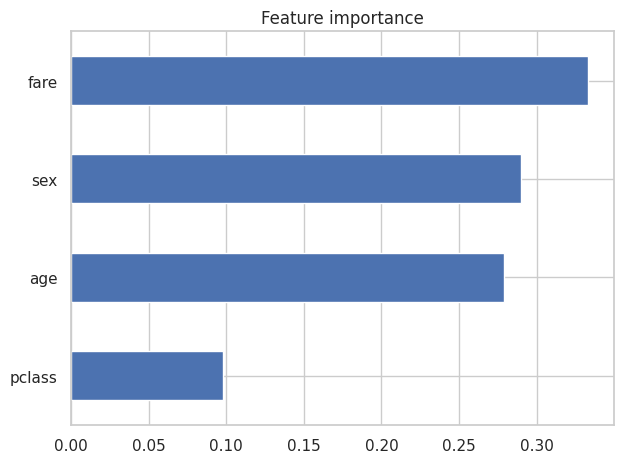

In [35]:

# -----------------------------------------------------------
# 🔹 5. END-TO-END MINI WORKFLOW
# -----------------------------------------------------------

# RAW  -> load the table (Pandas)
data = sns.load_dataset('titanic')

# CLEAN -> keep a few features, fill/drop missing, encode 'sex' (Pandas + NumPy)
data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)   # encode to numbers
data = data.dropna()

# SPLIT -> features X and target y as NumPy arrays (NumPy)
X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL -> fit + predict + score (scikit-learn)
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))

# OUTPUT -> the result, plus a quick feature-importance chart (Matplotlib)
print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout(); plt.show()